# Galaxy Classification and Data Visualization

This notebook contains tools for the analysis, classification, and visualization of galaxy spectroscopic properties.

The workflow focuses on the use of emission-line diagnostics to identify the dominant ionization source within galaxies and on the visualization of derived physical parameters.

### Workflow

* Part 1: Visualization and exploration of spectroscopic and physical properties, including table creation, emission-line annotations, multi-panel figures, and correlations between parameters such as star formation rate (SFR), redshift and neutral hydrogen levels.
  
* Part 3: Calculation of emission-line ratios from optical spectra and construction of BPT diagnostic diagrams using lines [OIII]/H$\beta$ and [NII]/H$\alpha$. Classification of galaxies into star-forming, composite, and AGN regions based on standard diagnostic criteria.

In [2]:
#Import libraries
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd

First we want to visualize the results of all of our fits, including the emission lines and the Lyman$\alpha$ region including the neutral hydrogen calculated in each fit.

In [4]:
#Select all created files
archivos = sorted(glob.glob("*.txt"))

tabla = []

for archivo in archivos:

    df = pd.read_csv(archivo, sep="\t")

    tabla.append({
        "Name": str(df["Name"].iloc[0]).replace(".spec.fits", ""),
        "z": df["z"].iloc[0],
        r"Flux H$\alpha$": df["Fluxha"].iloc[0],
        "Flux [OIII]": df["FluxOIII"].iloc[0],
        "Flux [OII]": df["FluxOII"].iloc[0],
        r"Flux H$\beta$": df["Hbeta"].iloc[0],
        r"Luminosity $H\alpha$": df["Lumha"].iloc[0],
        r"SFR H$\alpha$": df["SFRha"].iloc[0],
        "$N_{H}$": df["Columden"].iloc[0],
        "Reduced $\chi^2$":df["ErrorVoigt"].iloc[0],
    })

tabla = pd.DataFrame(tabla)
tabla[:10]

,Name,z,Flux H$\alpha$,Flux [OIII],Flux [OII],Flux H$\beta$,Luminosity $H\alpha$,SFR H$\alpha$,$N_{H}$,Reduced $\chi^2$
0,abell2744-ddt-v1_prism-clear_2756_110003,5.6600,5.114060e-18,1.087830e-17,1.277767e-18,9.665472e-19,1.857836e+42,14.676906,1.438450e+20,2.049904
1,ceers-lr-v1_prism-clear_1345_31329,6.1400,7.971596e-18,1.778538e-17,1.687418e-18,2.030662e-18,3.501492e+42,27.661784,2.636651e+21,1.964590
2,ceers-lr-v1_prism-clear_1345_397,6.0084,1.242052e-17,2.897688e-17,2.590788e-18,-1.746078e-17,5.187176e+42,40.978689,1.438450e+20,2.567777
3,ceers-lr-v1_prism-clear_1345_403,5.7680,3.608651e-18,5.293589e-18,1.898288e-18,4.250864e-19,1.370141e+42,10.824116,5.455595e+21,14.336701
4,ceers-lr-v1_prism-clear_1345_545,5.6666,7.793837e-18,1.733256e-17,3.414437e-18,1.523209e-18,2.839069e+42,22.428647,1.274275e+21,1.951560
5,gds-deep-lr-v1_prism-clear_1210_13618,5.9482,5.896540e-19,1.194607e-18,3.564286e-19,8.467618e-20,2.405433e+41,1.900292,2.636651e+21,5.642813
6,gds-deep-lr-v1_prism-clear_1210_13620,5.9204,6.080697e-19,1.376835e-18,3.157995e-19,1.047006e-19,2.453604e+41,1.938348,2.976351e+20,3.413873
7,gds-deep-lr-v1_prism-clear_1210_15338,5.0756,1.782721e-18,3.631342e-18,1.459078e-19,7.504581e-19,5.016405e+41,3.962960,1.128838e+22,8.761323
8,gds-deep-lr-v1_prism-clear_1210_8253,6.3300,6.362110e-19,9.350217e-19,9.408586e-20,2.633529e-19,1.790236e+41,1.414286,6.158482e+20,3.310527
9,gds-deep-lr-v1_prism-clear_1210_9842,5.8051,2.487319e-18,5.776171e-18,5.295033e-19,5.352764e-19,9.586342e+41,7.573210,2.636651e+21,2.185214


In [5]:
archivos = glob.glob("*.txt")
SFR=[]
z=[]
CD=[]
for archivo in archivos:
    df = pd.read_csv(archivo, sep="\t")
    SFR.append(float(df["SFRha"].iloc[0]))
    z.append(float(df["z"].iloc[0]))
    CD.append(float(df["Columden"].iloc[0]))
    labels = sorted(range(1, len(archivos)+1), key=str)

z=np.array(z)

In [6]:
print("In total we have", len(tabla), "galaxies for our study between",z.min(),"< z <",z.max())

In total we have 30 galaxies for our study between 5.0033 < z < 7.2053


## Searching for correlations

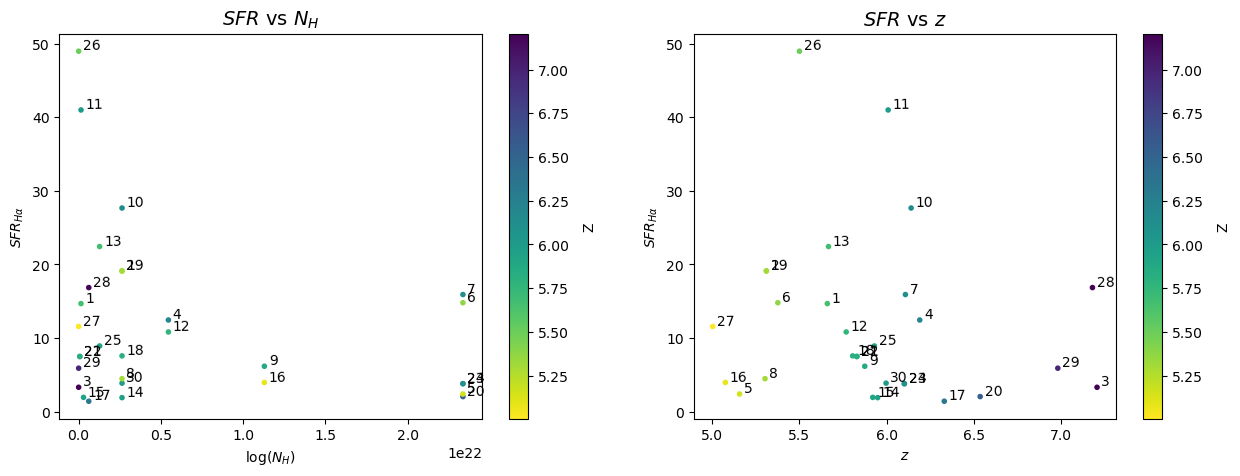

In [8]:
#Quick plot to see the points
# SFR vs NH

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sc1 = ax[0].scatter(CD, SFR, s=9, c=z, cmap='viridis_r', alpha=1)

cbar1 = fig.colorbar(sc1, ax=ax[0])
cbar1.set_label('Z', labelpad=10)

ax[0].set_xlabel(r'log($N_H$)')
ax[0].set_ylabel(r'$SFR_{H\alpha}$')
ax[0].set_title(r'$SFR$ vs $N_H$', fontsize=14)

for i, txt in enumerate(labels):
    ax[0].annotate(txt,
                 (CD[i], SFR[i]),
                 textcoords="offset points",
                 xytext=(3,1),
                 rotation=1)

# SFR vs z

sc2 = ax[1].scatter(z, SFR, s=9, c=z, cmap='viridis_r')

cbar2 = fig.colorbar(sc2, ax=ax[1])
cbar2.set_label('Z', labelpad=10)

ax[1].set_xlabel(r'$z$')
ax[1].set_ylabel(r'$SFR_{H\alpha}$')
ax[1].set_title(r'$SFR$ vs $z$', fontsize=14)

for i, txt in enumerate(labels):
    ax[1].annotate(txt,
                 (z[i], SFR[i]),
                 textcoords="offset points",
                 xytext=(3,1),
                 rotation=1)

In [9]:
#Outlier test using Chauvenet criteria
from scipy.special import erfc

x = np.array(SFR)
labels_arr = np.array(labels)

mean = np.mean(x)
std = np.std(x, ddof=1)
N = len(x)

# Deviation in units of sigma
z_score = np.abs(x - mean) / std

# Two-sided probability of being this far or farther
prob = erfc(z_score / np.sqrt(2))

# Chauvenet criterion
criterion = 1 / (2 * N)

outliers = np.where(prob < criterion)[0]

print("Chauvenet criterion:", criterion)
print("Outlier indices:", outliers)
print("Outlier labels:", labels_arr[outliers])
print("Outlier values:", x[outliers])
print("Probabilities:", prob[outliers])

Chauvenet criterion: 0.016666666666666666
Outlier indices: [ 2 18]
Outlier labels: [11 26]
Outlier values: [40.97868896 48.9607418 ]
Probabilities: [0.01019134 0.00107423]


In [10]:
#Convert to array too so we can mask the lists
SFR = np.array(SFR)
CD = np.array(CD)

labels = np.array(labels)
mask = np.ones(len(SFR), dtype=bool)
mask[[2, 18]] = False   # removes object with indices 2 and 18
SFR = SFR[mask]
CD = CD[mask]
z = z[mask]

Text(2, -3, '28')

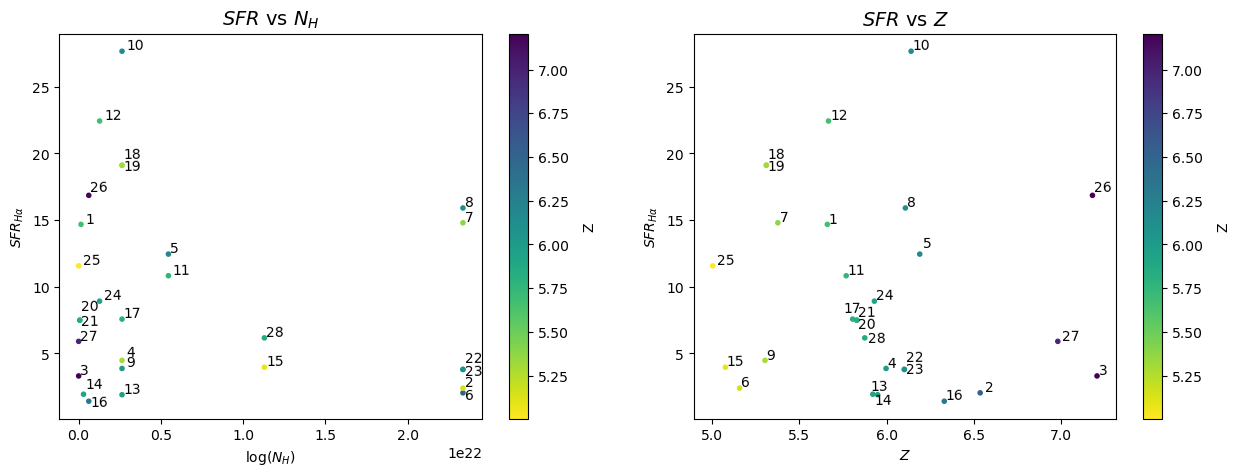

In [11]:
#In this section we build plots without outliers and the final samples
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sc1 = ax[0].scatter(CD, SFR, s=9, c=z, cmap='viridis_r', alpha=1)

cbar1 = fig.colorbar(sc1, ax=ax[0])
cbar1.set_label('Z', labelpad=10)

ax[0].set_xlabel("log($N_H$)")
ax[0].set_ylabel(r"$SFR_{H\alpha}$")
ax[0].set_title(r"$SFR$ vs $N_H$",fontsize=14)

ax[0].annotate(1, (CD[0], SFR[0]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[0].annotate(10, (CD[1], SFR[1]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[0].annotate(11, (CD[2], SFR[2]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[0].annotate(12, (CD[3], SFR[3]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[0].annotate(13, (CD[4], SFR[4]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(14, (CD[5], SFR[5]),textcoords="offset points", xytext=(1,4),rotation=1)
ax[0].annotate(15, (CD[6], SFR[6]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(16, (CD[7], SFR[7]),textcoords="offset points", xytext=(1,-4),rotation=1)
ax[0].annotate(17, (CD[8], SFR[8]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(18, (CD[9], SFR[9]),textcoords="offset points", xytext=(1,5),rotation=1)
ax[0].annotate(19, (CD[10], SFR[10]),textcoords="offset points", xytext=(1,-4),rotation=1)
ax[0].annotate(2, (CD[11], SFR[11]),textcoords="offset points", xytext=(1,5),rotation=1)
ax[0].annotate(20, (CD[12], SFR[12]),textcoords="offset points", xytext=(1,7),rotation=1)
ax[0].annotate(21, (CD[13], SFR[13]),textcoords="offset points", xytext=(1,-4),rotation=1)
ax[0].annotate(22, (CD[14], SFR[14]),textcoords="offset points", xytext=(1,5),rotation=1)
ax[0].annotate(23, (CD[15], SFR[15]),textcoords="offset points", xytext=(1,-4),rotation=1)
ax[0].annotate(24, (CD[16], SFR[16]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[0].annotate(25, (CD[17], SFR[17]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[0].annotate(26, (CD[18], SFR[18]),textcoords="offset points", xytext=(1,3),rotation=1)
ax[0].annotate(27, (CD[19], SFR[19]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(3, (CD[20], SFR[20]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(4, (CD[21], SFR[21]),textcoords="offset points", xytext=(3,9),rotation=1)
ax[0].annotate(5, (CD[22], SFR[22]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(6, (CD[23], SFR[23]),textcoords="offset points", xytext=(1,-8),rotation=1)
ax[0].annotate(7, (CD[24], SFR[24]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(8, (CD[25], SFR[25]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[0].annotate(9, (CD[26], SFR[26]),textcoords="offset points", xytext=(3,-4),rotation=1)
ax[0].annotate(28, (CD[27], SFR[27]),textcoords="offset points", xytext=(1,1),rotation=1)
#plt.savefig('SFRvsCD.png', dpi=300)

sc2 = ax[1].scatter(z, SFR, s=9, c=z, cmap='viridis_r')

cbar2 = fig.colorbar(sc2, ax=ax[1])
cbar2.set_label('Z', labelpad=10)

ax[1].set_xlabel("$Z$",font='Arial')
ax[1].set_ylabel(r"$SFR_{H\alpha}$")
ax[1].set_title(r"$SFR$ vs $Z$",fontsize=14)

#for i, txt in enumerate(n):
 #   plt.annotate(txt, (z[i], SFR[i]),textcoords="offset points", xytext=(3,1))
ax[1].annotate(1, (z[0], SFR[0]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(10, (z[1], SFR[1]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(11, (z[2], SFR[2]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(12, (z[3], SFR[3]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(13, (z[4], SFR[4]),textcoords="offset points", xytext=(-5,3),rotation=1)
ax[1].annotate(14, (z[5], SFR[5]),textcoords="offset points", xytext=(1,-7),rotation=1)
ax[1].annotate(15, (z[6], SFR[6]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(16, (z[7], SFR[7]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(17, (z[8], SFR[8]),textcoords="offset points", xytext=(-7,5),rotation=1)
ax[1].annotate(18, (z[9], SFR[9]),textcoords="offset points", xytext=(1,5),rotation=1)
ax[1].annotate(19, (z[10], SFR[10]),textcoords="offset points", xytext=(1,-4),rotation=1)
ax[1].annotate(2, (z[11], SFR[11]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[1].annotate(20, (z[12], SFR[12]),textcoords="offset points", xytext=(1,-6),rotation=1)
ax[1].annotate(21, (z[13], SFR[13]),textcoords="offset points", xytext=(1,3),rotation=1)
ax[1].annotate(22, (z[14], SFR[14]),textcoords="offset points", xytext=(1,6),rotation=1)
ax[1].annotate(23, (z[15], SFR[15]),textcoords="offset points", xytext=(1,-3),rotation=1)
ax[1].annotate(24, (z[16], SFR[16]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(25, (z[17], SFR[17]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[1].annotate(26, (z[18], SFR[18]),textcoords="offset points", xytext=(1,3),rotation=1)
ax[1].annotate(27, (z[19], SFR[19]),textcoords="offset points", xytext=(3,1),rotation=1)
ax[1].annotate(3, (z[20], SFR[20]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(4, (z[21], SFR[21]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(5, (z[22], SFR[22]),textcoords="offset points", xytext=(2,5),rotation=1)
ax[1].annotate(6, (z[23], SFR[23]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(7, (z[24], SFR[24]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(8, (z[25], SFR[25]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(9, (z[26], SFR[26]),textcoords="offset points", xytext=(1,1),rotation=1)
ax[1].annotate(28, (z[27], SFR[27]),textcoords="offset points", xytext=(2,-3),rotation=1)
#plt.savefig('SFRvsz.png', dpi=300)

In [12]:
from scipy.stats import spearmanr
print(spearmanr(CD, SFR))
print(spearmanr(z, SFR))
print(spearmanr(z, CD))

SignificanceResult(statistic=-0.06686667460918407, pvalue=0.7353087774803944)
SignificanceResult(statistic=-0.23360263124655728, pvalue=0.2315435151047661)
SignificanceResult(statistic=-0.08102797816269869, pvalue=0.6818889889779403)


No statistically significant correlation was found between variables since p-values are too high p>0.05.

## BPT diagram

We build a BPT diagram for classification of galaxies using 3$\sigma$ upper limits.

Text(0.5, 1.0, 'BPT diagram with 3$\\sigma$ limits')

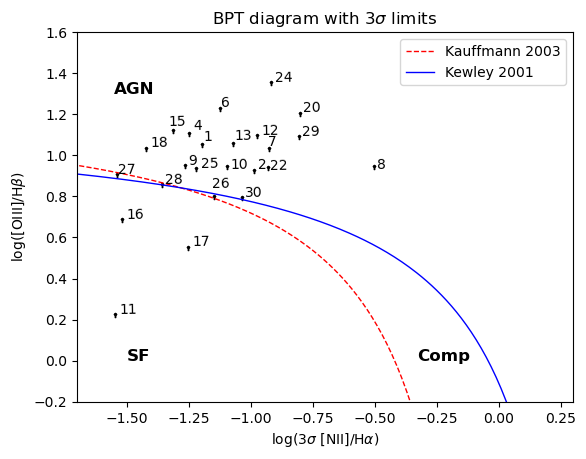

In [16]:
archivos = glob.glob("*.txt")
falfa=[]
fbeta=[]
fOIII=[]
fn=[]
w=[]
sigma3=[]


for archivo in archivos:    
    data1 = np.genfromtxt(archivo, skip_header=1)  
    falfa.append(data1[2])
    fbeta.append(data1[8])
    fOIII.append(data1[4])
    sigma3.append(data1[15])
    w.append(data1[16])
    


#Calcultate quotients
x=[]
y=[]
kewley_y=[]
kauffmann_y=[]
for i in range(len(archivos)):
    fn=np.sqrt(2*np.pi)*sigma3[i]*w[i]*1e4
    y.append(np.log10(fOIII[i]/abs(fbeta[i])))
    x.append(np.log10(fn/falfa[i]))   
       
plt.scatter(x,y,color='black',s=9,marker=r"$\uparrow$")  

#BPT lines
y_max=1.6
y_min=-0.2
x_max=0.3#0.3
x_min=-1.7

plt.ylim(y_min,y_max)
plt.xlim(x_min,x_max)


x_a=np.arange(-5,0.049,.01)
x_b=np.arange(-5,0.469,0.01)

k03=0.61/(x_a-0.05)+1.3
ke01=0.61/(x_b-0.47)+1.19

plt.plot(x_a,k03,"r--",label='Kauffmann 2003',lw=1)
plt.plot(x_b,ke01,"blue",label='Kewley 2001',lw=1)

plt.legend()

plt.annotate(1, (x[0], y[0]),textcoords="offset points", xytext=(1,3),rotation=1)
plt.annotate(10, (x[1], y[1]),textcoords="offset points", xytext=(2,-1),rotation=1)
plt.annotate(11, (x[2], y[2]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(12, (x[3], y[3]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(13, (x[4], y[4]),textcoords="offset points", xytext=(1,3),rotation=1)
plt.annotate(14, (x[5], y[5]),textcoords="offset points", xytext=(3,-4),rotation=1)
plt.annotate(15, (x[6], y[6]),textcoords="offset points", xytext=(-3,4),rotation=1)
plt.annotate(16, (x[7], y[7]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(17, (x[8], y[8]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(18, (x[9], y[9]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(19, (x[10], y[10]),textcoords="offset points", xytext=(0,2),rotation=1)
plt.annotate(2, (x[11], y[11]),textcoords="offset points", xytext=(3,2),rotation=1)
plt.annotate(20, (x[12], y[12]),textcoords="offset points", xytext=(2,1),rotation=1)
plt.annotate(21, (x[13], y[13]),textcoords="offset points", xytext=(3,3),rotation=0)
plt.annotate(22, (x[14], y[14]),textcoords="offset points", xytext=(1,-1),rotation=1)
plt.annotate(23, (x[15], y[15]),textcoords="offset points", xytext=(1,1),rotation=1)
plt.annotate(24, (x[16], y[16]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(25, (x[17], y[17]),textcoords="offset points", xytext=(3,1),rotation=1)
plt.annotate(26, (x[18], y[18]),textcoords="offset points", xytext=(-1,7),rotation=1)
plt.annotate(27, (x[19], y[19]),textcoords="offset points", xytext=(1,1),rotation=1)
plt.annotate(3, (x[20], y[20]),textcoords="offset points", xytext=(1,1),rotation=1)
plt.annotate(4, (x[21], y[21]),textcoords="offset points", xytext=(3,3),rotation=1)
plt.annotate(5, (x[22], y[22]),textcoords="offset points", xytext=(2,-4),rotation=1)
plt.annotate(6, (x[23], y[23]),textcoords="offset points", xytext=(1,2),rotation=1)
plt.annotate(7, (x[24], y[24]),textcoords="offset points", xytext=(-1,2),rotation=1)
plt.annotate(8, (x[25], y[25]),textcoords="offset points", xytext=(2,-1),rotation=1)
plt.annotate(9, (x[26], y[26]),textcoords="offset points", xytext=(2,1),rotation=1)
plt.annotate(28, (x[27], y[27]),textcoords="offset points", xytext=(2,1),rotation=1)
plt.annotate(29, (x[28], y[28]),textcoords="offset points", xytext=(2,1),rotation=1)
plt.annotate(30, (x[29], y[29]),textcoords="offset points", xytext=(2,1),rotation=1)

plt.text(-1.55, 1.3, "AGN", fontsize=12, color="black",weight='bold')
plt.text(-1.5, 0, "SF", fontsize=12, color="black",weight='bold')
plt.text(-0.33, 0, "Comp", fontsize=12, color="black",weight='bold')
plt.ylabel(r'log([OIII]/H$\beta$)')
plt.xlabel(r"log(3$\sigma$ [NII]/H$\alpha$)")
plt.title('BPT diagram with 3$\sigma$ limits')
#plt.savefig('BPT.png', dpi=300) #Save image

    

Even if the BPT diagram shows most galaxies in the AGN region, the spectra of our galaxy does not show broad lines in H$\alpha$ emission line and other typical lines present of quasars. Which lead us to conclude that our objects in the sample are not AGN. 